<h1><b>Rail Corrugation Model Training</b></h1>

<h4><b>Background Information</b></h4>

The rail corrugation subsystem in NEBULA X Problem Statement 3 asks whether each one-second recording of
axle-box vibration and shock shows corrugation on the Side I rail, on the Side II rail, or on neither.
Predictions are scored with macro F1 over the three classes, which weights the two rare fault classes as much
as the common Normal class. The 272 labelled Train recordings hold 234 Normal, 14 Side I and 24 Side II
recordings, and the 68 Test recordings are unlabelled.

<h4><b>Objective</b></h4>

This notebook builds classifiers from simple rules upwards and evaluates each one on the four grouped
validation folds defined during preprocessing, using macro F1. Every model architecture is tracked as its own
MLflow experiment on DagsHub (`rc_baseline`, `rc_logistic_regression`, `rc_gradient_boosting`,
`rc_attention_mil`), the architectures are compared, and the selected model is refitted, registered and used to
classify the Test recordings.

<h4><b>Project Workflow</b></h4>

The notebook sets up the environment and experiment tracking, loads the preprocessed recordings and features,
defines the performance metrics and the shared model utilities, and then builds four architectures of
increasing complexity: simple rules, a regularised logistic regression and gradient-boosted trees on the
recording features, and the team's attention-based deep network, which learns from the raw signal of every
axle box. The architectures are then compared, one is selected, refitted and registered, and the Test
predictions are produced.

<h4><b>Dataset Used</b></h4>

The inputs are the outputs of `rail_corrugation_preprocessing.ipynb` in `data/processed/rail`: the recording
table with speeds, fingerprints, labels and folds, the recording feature table and the channel table. The deep
network reads the raw recordings in `PS3/02_Datasets/Rail_Corrugation`, and `Train_Labels.csv` is used to confirm
the labels.

<h4><b>Table of Contents</b></h4>
<ul>
  <li><a href="#section-1">Section 1: Environment Setup</a>
    <ul>
      <li><a href="#1-1">1.1 Libraries and Settings</a></li>
      <li><a href="#1-2">1.2 Paths and Configuration</a></li>
      <li><a href="#1-3">1.3 Experiment Tracking</a></li>
    </ul>
  </li>
  <li><a href="#section-2">Section 2: Data and Features</a>
    <ul>
      <li><a href="#2-1">2.1 Preprocessed Tables</a></li>
      <li><a href="#2-2">2.2 Source Check and Data Version</a></li>
      <li><a href="#2-3">2.3 Labels and Classes</a></li>
      <li><a href="#2-4">2.4 Speed and Class</a></li>
      <li><a href="#2-5">2.5 Feature Sets</a></li>
      <li><a href="#2-6">2.6 Side Contrasts by Class</a></li>
    </ul>
  </li>
  <li><a href="#section-3">Section 3: Performance Metrics</a>
    <ul>
      <li><a href="#3-1">3.1 Macro F1</a></li>
      <li><a href="#3-2">3.2 Held-Out Summary</a></li>
      <li><a href="#3-3">3.3 Evaluation Plots</a></li>
      <li><a href="#3-4">3.4 Recording Evaluations in MLflow</a></li>
    </ul>
  </li>
  <li><a href="#section-4">Section 4: Model Utilities</a>
    <ul>
      <li><a href="#4-1">4.1 Validation Folds</a></li>
      <li><a href="#4-2">4.2 Model Inputs</a></li>
      <li><a href="#4-3">4.3 Cross-Validation</a></li>
      <li><a href="#4-4">4.4 Experiment Runner</a></li>
    </ul>
  </li>
  <li><a href="#section-5">Section 5: Baseline: Simple Rules</a>
    <ul>
      <li><a href="#5-1">5.1 Majority Class</a></li>
      <li><a href="#5-2">5.2 Side-Contrast Rule</a></li>
    </ul>
  </li>
  <li><a href="#section-6">Section 6: Logistic Regression</a>
    <ul>
      <li><a href="#6-1">6.1 Logistic Classifier</a></li>
      <li><a href="#6-2">6.2 All Features</a></li>
      <li><a href="#6-3">6.3 Feature-Group Ablations</a></li>
      <li><a href="#6-4">6.4 Coefficients</a></li>
    </ul>
  </li>
  <li><a href="#section-7">Section 7: Gradient Boosting</a>
    <ul>
      <li><a href="#7-1">7.1 LightGBM Classifier</a></li>
      <li><a href="#7-2">7.2 All Features</a></li>
      <li><a href="#7-3">7.3 Without Speed</a></li>
      <li><a href="#7-4">7.4 Feature Importance</a></li>
    </ul>
  </li>
  <li><a href="#section-8">Section 8: Attention-Based Deep Network</a>
    <ul>
      <li><a href="#8-1">8.1 Signal Tensors</a></li>
      <li><a href="#8-2">8.2 Network Architecture</a></li>
      <li><a href="#8-3">8.3 Training and Decision Rule</a></li>
      <li><a href="#8-4">8.4 Cross-Validated Training</a></li>
      <li><a href="#8-5">8.5 Training Curves</a></li>
      <li><a href="#8-6">8.6 Attention by Axle Box</a></li>
    </ul>
  </li>
  <li><a href="#section-9">Section 9: Model Comparison</a>
    <ul>
      <li><a href="#9-1">9.1 Results Across Experiments</a></li>
      <li><a href="#9-2">9.2 Comparison Plot</a></li>
      <li><a href="#9-3">9.3 Model Selection</a></li>
    </ul>
  </li>
  <li><a href="#section-10">Section 10: Final Model</a>
    <ul>
      <li><a href="#10-1">10.1 Refit on All Train Recordings</a></li>
      <li><a href="#10-2">10.2 Model Package</a></li>
      <li><a href="#10-3">10.3 Registration</a></li>
      <li><a href="#10-4">10.4 Submission Format</a></li>
      <li><a href="#10-5">10.5 Package Checks</a></li>
      <li><a href="#10-6">10.6 Test Predictions</a></li>
      <li><a href="#10-7">10.7 Test Predictions by Speed</a></li>
    </ul>
  </li>
  <li><a href="#section-11">Section 11: Conclusions</a>
    <ul>
      <li><a href="#11-1">11.1 Results by Architecture</a></li>
      <li><a href="#11-2">11.2 Selected Model and Test Predictions</a></li>
      <li><a href="#11-3">11.3 Limitations</a></li>
    </ul>
  </li>
</ul>

<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-1" style="color: black;"><b>Section 1: Environment Setup</b></h2>
</div>

This section imports the libraries, locates the data, fixes the settings used throughout, and connects MLflow to
the project's DagsHub repository.

<blockquote><h3 id="1-1"><b>1.1 Libraries and Settings</b></h3></blockquote>

The notebook uses pandas and NumPy for data handling, scikit-learn and LightGBM for the feature-based models,
TensorFlow with Keras for the deep network, and MLflow with DagsHub for experiment tracking. A fixed seed and
deterministic TensorFlow operations make every result reproducible. TensorFlow's internal log messages are
switched off, together with its graph rewriter, which only reports failed rewrites here and does not change the
training speed.

In [1]:
import os
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')  # keep TensorFlow's C++ log lines out of the notebook

from pathlib import Path
import io
import json
import time
import uuid
import hashlib
import logging
import warnings
import contextlib
import subprocess
import importlib.metadata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, precision_recall_fscore_support, confusion_matrix
from sklearn.model_selection import train_test_split
import tensorflow as tf
import keras
from keras import layers
import mlflow
import mlflow.pyfunc
from mlflow import MlflowClient
from mlflow.models import infer_signature
from IPython.display import display

SEED = 2026
keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()
tf.config.optimizer.set_experimental_options({'disable_meta_optimizer': True})
CLASSES = ['Normal', 'Side I', 'Side II']
CLASS_KEYS = {'Normal': 'normal', 'Side I': 'side_i', 'Side II': 'side_ii'}
COLORS = {'candidate': '#2878a5', 'variant': '#9a9a9a'}
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'figure.constrained_layout.use': True})
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 120)
pd.set_option('display.width', 170)
for logger_name in ['mlflow', 'alembic']:
    logging.getLogger(logger_name).setLevel(logging.WARNING)  # MLflow resets its level on import, so set it after
tf.get_logger().setLevel(logging.ERROR)  # hides retracing notices from building one network per fold

<blockquote><h3 id="1-2"><b>1.2 Paths and Configuration</b></h3></blockquote>

The data folders are found from the working directory; `TFD_PS3_DIR` and `TFD_PROCESSED_DIR` override them. Every
setting that affects the results is gathered in one configuration, which each MLflow run records.

In [2]:
def find_repo_root():
    """Nearest ancestor of the working directory that holds `pyproject.toml`."""
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / 'pyproject.toml').is_file():
            return base
    return Path.cwd()


def find_dataset(subsystem):
    """Locate a PS3 subsystem folder from `TFD_PS3_DIR` or the working directory and its parents."""
    if os.environ.get('TFD_PS3_DIR'):
        root = Path(os.environ['TFD_PS3_DIR']).expanduser()
        candidates = [root / subsystem, root / '02_Datasets' / subsystem]
    else:
        suffixes = ['problem-statement/PS3/02_Datasets', 'PS3/02_Datasets', '02_Datasets']
        candidates = [base / suffix / subsystem for base in [Path.cwd(), *Path.cwd().parents] for suffix in suffixes]
    for candidate in candidates:
        if candidate.is_dir():
            return candidate.resolve()
    raise FileNotFoundError(f'{subsystem} not found; set TFD_PS3_DIR to the PS3 or 02_Datasets folder.')


REPO_ROOT = find_repo_root()
RAIL_DIR = find_dataset('Rail_Corrugation')
PROCESSED_DIR = Path(os.environ.get('TFD_PROCESSED_DIR', REPO_ROOT / 'data' / 'processed')) / 'rail'
OUTPUT_DIR = PROCESSED_DIR / 'training'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    'seed': SEED,
    'registered_model': 'rc_corrugation_classifier',
    'dagshub': {'repo_owner': 'kaz-uuu', 'repo_name': 'lta-train-fault-detection'},
    'rule_feature': 'vibration_contrast_log_rms_median',
    'rule_k_grid': [1.0, 1.5, 2.0, 2.5, 3.0],
    'c_grid': [0.01, 0.1, 1.0],
    'lightgbm': {'n_estimators': 200, 'learning_rate': 0.05, 'num_leaves': 7, 'min_child_samples': 5,
                 'subsample': 0.8, 'subsample_freq': 1, 'colsample_bytree': 0.5, 'reg_lambda': 1.0},
    'signal': {'fs': 10000, 'teeth': 90, 'wheel_diameter_m': 0.85, 'fallback_speed_mps': 20.0,
               'raw_decimate': 5, 'distance_step_m': 0.005, 'max_distance_m': 20.0},
    'attention_mil': {'embed_dim': 64, 'attn_dim': 64, 'batch_size': 8, 'max_epochs': 150, 'learning_rate': 0.001,
                      'validation_share': 0.15, 'early_stopping_patience': 20, 'lr_patience': 8, 'lr_factor': 0.5,
                      'min_lr': 1e-6, 'focal_gamma': 2.0, 'threshold': 0.5},
    'bootstrap_draws': 10000,
}


def flatten(settings, prefix=''):
    """Nested settings as one mapping with dotted keys."""
    flat = {}
    for key, value in settings.items():
        flat.update(flatten(value, f'{prefix}{key}.') if isinstance(value, dict) else {f'{prefix}{key}': value})
    return flat


display(pd.Series(flatten(CONFIG), name='value').to_frame())

,value
seed,2026
registered_model,rc_corrugation_classifier
dagshub.repo_owner,kaz-uuu
dagshub.repo_name,lta-train-fault-detection
rule_feature,vibration_contrast_log_rms_median
rule_k_grid,"[1.0, 1.5, 2.0, 2.5, 3.0]"
c_grid,"[0.01, 0.1, 1.0]"
lightgbm.n_estimators,200
lightgbm.learning_rate,0.05
lightgbm.num_leaves,7


<blockquote><h3 id="1-3"><b>1.3 Experiment Tracking</b></h3></blockquote>

MLflow logs to the DagsHub repository `kaz-uuu/lta-train-fault-detection` through `dagshub.init`, using the login
stored on this machine by `dagshub login`. Each model architecture gets its own experiment named
`rc_<architecture>`, and each evaluated configuration is one run inside it. The runs of one execution share a
`notebook_run` tag so that the comparison later reads back exactly this execution. Setting `TFD_MLFLOW=local`
logs to a local SQLite store instead, and an explicit `MLFLOW_TRACKING_URI` takes precedence over both.

In [3]:
TRACKING = 'uri' if os.environ.get('MLFLOW_TRACKING_URI') else os.environ.get('TFD_MLFLOW', 'dagshub')
if TRACKING == 'dagshub':
    import dagshub
    dagshub.init(repo_owner=CONFIG['dagshub']['repo_owner'], repo_name=CONFIG['dagshub']['repo_name'], mlflow=True)
elif TRACKING == 'local':
    mlflow.set_tracking_uri(f"sqlite:///{(REPO_ROOT / 'mlflow.db').as_posix()}")
TRACKING_URI = mlflow.get_tracking_uri()
mlflow.set_registry_uri(TRACKING_URI)
client = MlflowClient()
NOTEBOOK_RUN = uuid.uuid4().hex[:8]


def git(*args):
    """Output of a git command run in the repository, or an empty string when git is unavailable."""
    try:
        return subprocess.run(['git', *args], cwd=REPO_ROOT, capture_output=True, text=True, timeout=10).stdout.strip()
    except (OSError, subprocess.SubprocessError):
        return ''


GIT = {'git_commit': git('rev-parse', '--short', 'HEAD') or 'unknown',
       'git_branch': git('rev-parse', '--abbrev-ref', 'HEAD') or 'unknown'}


def experiment_id(name):
    """Id of the MLflow experiment `name`, created on first use."""
    found = client.get_experiment_by_name(name)
    if found is not None:
        return found.experiment_id
    location = (REPO_ROOT / 'mlartifacts').as_uri() if TRACKING_URI.startswith('sqlite') else None
    return client.create_experiment(name, artifact_location=location)


print('Tracking to:', TRACKING_URI if TRACKING != 'local' else 'local SQLite store (mlflow.db)')
print('Runs of this execution are tagged notebook_run =', NOTEBOOK_RUN)

Accessing as kaz-uuu

Initialized MLflow to track repo "kaz-uuu/lta-train-fault-detection"

Repository kaz-uuu/lta-train-fault-detection initialized!

Tracking to: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow
Runs of this execution are tagged notebook_run = 9f6562e7


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-2" style="color: black;"><b>Section 2: Data and Features</b></h2>
</div>

This section loads the preprocessed tables, confirms they still match the raw recordings, checks the labels, and
assembles the feature sets. Several findings of the exploratory analysis shape the modelling: the classes are
heavily imbalanced; corrugated recordings occur only between about 35 and 67 km/h while Normal recordings span
every speed, so speed is confounded with the class; wavelength features are undefined for stationary recordings
and for long wavelengths at low speed; and two pairs of identical Normal recordings must stay in the same
validation fold.

<blockquote><h3 id="2-1"><b>2.1 Preprocessed Tables</b></h3></blockquote>

Three tables from the preprocessing notebook are read: the recording table, the recording feature table and,
from the channel table, the map of the 128 acceleration channels to their kind, car, position and rail side,
together with the preprocessing manifest.

In [4]:
files = pd.read_parquet(PROCESSED_DIR / 'rail_files.parquet')
features = pd.read_parquet(PROCESSED_DIR / 'rail_features.parquet')
channels = (pd.read_parquet(PROCESSED_DIR / 'rail_channel_features.parquet',
                            columns=['column', 'kind', 'car', 'position', 'side', 'axle'])
            .drop_duplicates('column').sort_values(['car', 'position', 'kind'], ascending=[True, True, False])
            .reset_index(drop=True))
prep_manifest = json.loads((PROCESSED_DIR / 'manifest.json').read_text())
display(pd.DataFrame({name: {'rows': len(t), 'columns': t.shape[1]} for name, t in {
    'recordings': files, 'recording features': features, 'channel map': channels}.items()}).T)

,rows,columns
recordings,340,20
recording features,340,106
channel map,128,6


<blockquote><h3 id="2-2"><b>2.2 Source Check and Data Version</b></h3></blockquote>

Every raw recording is read again and its values are fingerprinted as in preprocessing; a mismatch means the
preprocessed tables describe different data and stops the notebook. A short data version, derived from the
fingerprints of the preprocessed tables, is attached to every MLflow run.

In [5]:
def sha256_file(path):
    """SHA-256 of a file's bytes."""
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()


def read_recording(path):
    """One raw recording with its 129-column header."""
    return pd.read_csv(path, engine='pyarrow')


def values_sha256(frame):
    """Fingerprint of a recording's values, as computed during preprocessing."""
    return hashlib.sha256(frame.to_numpy(dtype=float).astype('<f8').tobytes()).hexdigest()


RAW_PATHS = {p.name: p for p in sorted(RAIL_DIR.glob('*/*.csv'))}
expected = files.set_index('filename')['sha256']
mismatched = [name for name, digest in expected.items() if values_sha256(read_recording(RAW_PATHS[name])) != digest]
assert not mismatched, f'Recordings changed since preprocessing: {mismatched}; rerun rail_corrugation_preprocessing.ipynb.'
TABLES = ['rail_files.parquet', 'rail_features.parquet', 'rail_channel_features.parquet']
DATA_VERSION = 'rc-' + hashlib.sha256(''.join(sha256_file(PROCESSED_DIR / t) for t in TABLES).encode()).hexdigest()[:8]
print(f'All {len(expected)} raw recordings match the preprocessing fingerprints; data version {DATA_VERSION}.')

All 340 raw recordings match the preprocessing fingerprints; data version rc-eddde385.


<blockquote><h3 id="2-3"><b>2.3 Labels and Classes</b></h3></blockquote>

The label of each Train recording is taken from the recording table and checked against `Train_Labels.csv`. The
table counts the recordings per class; macro F1 gives the 14 Side I and 24 Side II recordings the same weight as
the 234 Normal ones.

In [6]:
RECORDINGS = (files[['filename', 'dataset', 'speed_kmh', 'stationary', 'speed_band', 'accel_sha256', 'label', 'fold']]
              .rename(columns={'filename': 'file_id'}).astype({'file_id': str, 'dataset': str, 'speed_band': str}))
RECORDINGS['label'] = RECORDINGS['label'].astype(object).where(RECORDINGS['label'].notna(), None)
train_labels = RECORDINGS[RECORDINGS['dataset'].eq('Train')].set_index('file_id')['label']
raw_labels = pd.read_csv(RAIL_DIR / 'Train_Labels.csv', dtype=str).set_index('filename')['label']
assert raw_labels.reindex(train_labels.index).tolist() == train_labels.tolist()
display(pd.crosstab(RECORDINGS['dataset'], RECORDINGS['label'].fillna('unlabelled'), margins=True)[CLASSES + ['unlabelled', 'All']])

label,Normal,Side I,Side II,unlabelled,All
dataset,,,,,
Test,0,0,0,68,68
Train,234,14,24,0,272
All,234,14,24,68,340


<blockquote><h3 id="2-4"><b>2.4 Speed and Class</b></h3></blockquote>

The table counts the recordings of each class and of the Test set per speed band. Corrugated recordings appear
only above 20 km/h, and almost all of them between 40 and 80 km/h, while Normal recordings cover every band. A
model can therefore score well partly by learning speed; the learned models are also run without the speed
feature to measure how much they rely on it.

In [7]:
BANDS = ['stationary', '0.5-20', '20-40', '40-60', '60-80']
display(pd.crosstab(RECORDINGS['speed_band'], RECORDINGS['label'].fillna('Test')).reindex(BANDS)[CLASSES + ['Test']])
display(RECORDINGS.groupby(RECORDINGS['label'].fillna('Test'))['speed_kmh'].describe()[['min', '50%', 'max']]
        .reindex(CLASSES + ['Test']).round(1).rename(columns={'50%': 'median'}))

label,Normal,Side I,Side II,Test
speed_band,,,,
stationary,42,0,0,9
0.5-20,58,0,0,9
20-40,55,2,0,16
40-60,58,9,19,30
60-80,21,3,5,4


,min,median,max
label,,,
Normal,0.0,29.3,70.2
Side I,34.9,46.6,67.0
Side II,42.1,50.4,66.7
Test,0.0,40.1,67.7


<blockquote><h3 id="2-5"><b>2.5 Feature Sets</b></h3></blockquote>

The 101 recording features of preprocessing fall into six groups: speed, amplitude, waveform shape and spectral
shape of each rail side, wavelength-band power of each side, and same-axle side contrasts, which compare the
Side I and Side II ends of each axle. All features enter the learned models, which fit any imputation or scaling
on training folds only. The table counts missing values per group for moving and stationary recordings.

In [8]:
FEATURE_GROUPS = prep_manifest['feature_groups']
FEATURES = [f for columns in FEATURE_GROUPS.values() for f in columns]
FEATURE_TABLE = (features.rename(columns={'filename': 'file_id'}).astype({'file_id': str})[['file_id'] + FEATURES]
                 .merge(RECORDINGS[['file_id', 'dataset', 'label', 'fold', 'speed_band']], on='file_id'))
FEATURE_TABLE[FEATURES] = FEATURE_TABLE[FEATURES].astype(float)
assert len(FEATURES) == 101 and FEATURE_TABLE['file_id'].is_unique and len(FEATURE_TABLE) == len(RECORDINGS)
moving = FEATURE_TABLE['speed_band'].ne('stationary')
display(pd.DataFrame({group: {'features': len(columns),
                              'missing values (moving)': int(FEATURE_TABLE.loc[moving, columns].isna().sum().sum()),
                              'missing values (stationary)': int(FEATURE_TABLE.loc[~moving, columns].isna().sum().sum())}
                      for group, columns in FEATURE_GROUPS.items()}).T)

,features,missing values (moving),missing values (stationary)
speed,1,0,0
amplitude,12,0,0
waveform shape,12,0,0
spectral shape,20,0,0
wavelength power,24,664,1224
side contrast,32,664,1224


<blockquote><h3 id="2-6"><b>2.6 Side Contrasts by Class</b></h3></blockquote>

Corrugation on one rail should make the axle boxes on that side vibrate more than the opposite ends of the same
axles. The table gives, per class, the median of the same-axle contrasts of log RMS (Side I minus Side II) for
vibration and shock, and the median share of axles on which the Side I end is the louder one.

In [9]:
CONTRASTS = ['vibration_contrast_log_rms_median', 'shock_contrast_log_rms_median',
             'vibration_contrast_log_rms_pos_share', 'shock_contrast_log_rms_pos_share']
display(FEATURE_TABLE[FEATURE_TABLE['dataset'].eq('Train')].groupby('label')[CONTRASTS].median().reindex(CLASSES).round(3))

,vibration_contrast_log_rms_median,shock_contrast_log_rms_median,vibration_contrast_log_rms_pos_share,shock_contrast_log_rms_pos_share
label,,,,
Normal,-0.029,-0.094,0.469,0.375
Side I,-0.025,-0.083,0.469,0.375
Side II,-0.077,-0.091,0.406,0.344


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-3" style="color: black;"><b>Section 3: Performance Metrics</b></h2>
</div>

This section defines how every model is judged: the official macro F1 score, a summary of a model's held-out
predictions with its uncertainty, the evaluation plots, and the function that records an evaluation in MLflow.

<blockquote><h3 id="3-1"><b>3.1 Macro F1</b></h3></blockquote>

The official score is the unweighted mean of the F1 scores of Normal, Side I and Side II, so a class that is never
predicted correctly contributes 0. The implementation is checked on a small example worked by hand, against a
direct computation from the confusion matrix on random predictions, and against the 0.308 that always predicting
Normal scores on the Train labels.

In [10]:
def macro_f1(y_true, y_pred):
    """Official rail score: the unweighted mean of the F1 scores of Normal, Side I and Side II."""
    return float(f1_score(y_true, y_pred, labels=CLASSES, average='macro', zero_division=0))


def macro_f1_from_confusion(y_true, y_pred):
    """The same score computed directly from the confusion matrix."""
    cm = confusion_matrix(y_true, y_pred, labels=CLASSES)
    tp = np.diag(cm)
    denominator = 2 * tp + (cm.sum(axis=0) - tp) + (cm.sum(axis=1) - tp)
    return float(np.mean(np.where(denominator > 0, 2 * tp / np.maximum(denominator, 1), 0.0)))


TRAIN_LABELS = RECORDINGS.loc[RECORDINGS['dataset'].eq('Train'), 'label'].to_numpy()
random_predictions = np.random.default_rng(SEED).choice(CLASSES, size=len(TRAIN_LABELS))
ALWAYS_NORMAL = macro_f1(TRAIN_LABELS, np.full(len(TRAIN_LABELS), 'Normal'))
checks = {
    'perfect predictions score 1': macro_f1(TRAIN_LABELS, TRAIN_LABELS) == 1.0,
    'hand-worked example scores 5/9': np.isclose(macro_f1(['Normal', 'Side I', 'Side II'], ['Normal', 'Normal', 'Side II']), 5 / 9),
    'matches the confusion-matrix computation': np.isclose(macro_f1(TRAIN_LABELS, random_predictions),
                                                           macro_f1_from_confusion(TRAIN_LABELS, random_predictions)),
    'always Normal on the Train labels scores 0.308': np.isclose(ALWAYS_NORMAL, 0.3083, atol=1e-4),
}
assert all(checks.values())
display(pd.Series(checks, name='passed').to_frame())

,passed
perfect predictions score 1,True
hand-worked example scores 5/9,True
matches the confusion-matrix computation,True
always Normal on the Train labels scores 0.308,True


<blockquote><h3 id="3-2"><b>3.2 Held-Out Summary</b></h3></blockquote>

The out-of-fold predictions of a model for all 272 Train recordings are pooled and scored once, as the Test set
is. With 14 Side I and 24 Side II recordings, the score needs its uncertainty next to it: a bootstrap resamples
recordings within each class 10,000 times to give a 95% interval. The summary also reports the F1, precision and
recall of each class, the accuracy, and the mean and spread of macro F1 over the four folds.

In [11]:
def bootstrap_interval(y_true, y_pred, draws, seed):
    """95% percentile interval of macro F1 when recordings are resampled within each class."""
    rng = np.random.default_rng(seed)
    t, p = pd.Categorical(y_true, CLASSES).codes, pd.Categorical(y_pred, CLASSES).codes
    samples = np.concatenate([rng.choice(np.flatnonzero(t == k), size=(draws, int((t == k).sum())))
                              for k in range(len(CLASSES))], axis=1)
    ts, ps = t[samples], p[samples]
    f1 = []
    for k in range(len(CLASSES)):
        tp = ((ts == k) & (ps == k)).sum(axis=1)
        denominator = 2 * tp + ((ts != k) & (ps == k)).sum(axis=1) + ((ts == k) & (ps != k)).sum(axis=1)
        f1.append(np.where(denominator > 0, 2 * tp / np.maximum(denominator, 1), 0.0))
    return np.percentile(np.mean(f1, axis=0), [2.5, 97.5])


def summarise(predictions):
    """Headline numbers of one evaluation from its pooled out-of-fold predictions."""
    y, p = predictions['label'].to_numpy(), predictions['prediction'].to_numpy()
    precision, recall, f1, _ = precision_recall_fscore_support(y, p, labels=CLASSES, zero_division=0)
    by_fold = predictions.groupby('fold').apply(lambda g: macro_f1(g['label'], g['prediction']), include_groups=False)
    low, high = bootstrap_interval(y, p, CONFIG['bootstrap_draws'], SEED)
    summary = {'macro_f1': macro_f1(y, p), 'macro_f1_ci_low': float(low), 'macro_f1_ci_high': float(high),
               'macro_f1_fold_mean': float(by_fold.mean()), 'macro_f1_fold_std': float(by_fold.std(ddof=1)),
               'accuracy': float((y == p).mean()), 'n_recordings': len(y), 'n_folds': int(by_fold.size)}
    for k, cls in enumerate(CLASSES):
        key = CLASS_KEYS[cls]
        summary.update({f'f1_{key}': float(f1[k]), f'precision_{key}': float(precision[k]), f'recall_{key}': float(recall[k])})
    return summary

<blockquote><h3 id="3-3"><b>3.3 Evaluation Plots</b></h3></blockquote>

Two plots recur throughout: the confusion matrix of the pooled out-of-fold predictions, which shows which classes
a model confuses, and a bar chart of pooled macro F1 with intervals, which compares models against the score of
always predicting Normal.

In [12]:
def confusion_figure(predictions, title):
    """Confusion matrix of pooled out-of-fold predictions (rows: true class, columns: predicted class)."""
    cm = confusion_matrix(predictions['label'], predictions['prediction'], labels=CLASSES)
    fig, ax = plt.subplots(figsize=(3.6, 3.1))
    ax.imshow(cm, cmap='Blues')
    for i in range(len(CLASSES)):
        for j in range(len(CLASSES)):
            ax.text(j, i, cm[i, j], ha='center', va='center', color='white' if cm[i, j] > cm.max() / 2 else 'black')
    ax.set(xticks=range(len(CLASSES)), yticks=range(len(CLASSES)), xticklabels=CLASSES, yticklabels=CLASSES,
           xlabel='Predicted class', ylabel='True class')
    ax.set_title(title, fontsize=9)
    return fig


def comparison_figure(table):
    """Pooled macro F1 per run with bootstrap intervals; candidates coloured, variants grey."""
    fig, ax = plt.subplots(figsize=(10, 3.6))
    x = np.arange(len(table))
    ax.bar(x, table['macro F1'], color=[COLORS['candidate'] if r == 'candidate' else COLORS['variant'] for r in table['role']])
    ax.errorbar(x, table['macro F1'], yerr=[table['macro F1'] - table['CI low'], table['CI high'] - table['macro F1']],
                fmt='none', ecolor='black', capsize=3, linewidth=1)
    ax.axhline(ALWAYS_NORMAL, color='black', linestyle='--', linewidth=1, label=f'always Normal ({ALWAYS_NORMAL:.3f})')
    ax.set(xticks=x, ylim=(0, 1.05), ylabel='Pooled out-of-fold macro F1')
    ax.set_xticklabels(table.index, rotation=30, ha='right', fontsize=8)
    ax.legend(loc='lower left', bbox_to_anchor=(0, 1.0), frameon=False)
    return fig

<blockquote><h3 id="3-4"><b>3.4 Recording Evaluations in MLflow</b></h3></blockquote>

Each evaluated configuration becomes one run in the experiment of its architecture. The run records the
configuration as parameters, the headline numbers and the macro F1 of every fold as metrics, the per-fold table,
the out-of-fold predictions, any model-specific tables and the confusion matrix, together with tags for the code
version, data version, split and role. The role is `candidate` for configurations that compete for selection and
`variant` for diagnostic runs.

In [13]:
def log_evaluation(experiment, run_name, result, params, role, tables=None):
    """Record one evaluated configuration as a run of `experiment` and return the run id."""
    tags = {'notebook_run': NOTEBOOK_RUN, **GIT, 'data_version': DATA_VERSION, 'split': result['split'], 'role': role}
    with mlflow.start_run(experiment_id=experiment_id(experiment), run_name=run_name, tags=tags) as run:
        mlflow.log_params({**params, 'split': result['split'], 'seed': SEED})
        mlflow.log_metrics({**result['summary'], 'fit_time_s': result['fit_time_s'],
                            **{f'macro_f1_fold_{fold}': value for fold, value in result['per_fold']['macro_f1'].items()}})
        mlflow.log_text(result['per_fold'].reset_index().to_csv(index=False), 'per_fold.csv')
        mlflow.log_text(result['predictions'].to_csv(index=False), 'predictions.csv')
        for name, table in (tables or {}).items():
            mlflow.log_text(table.to_csv(), f'{name}.csv')
        fig = confusion_figure(result['predictions'], f'{experiment} / {run_name}')
        mlflow.log_figure(fig, 'confusion_matrix.png')
        plt.close(fig)
    return run.info.run_id

<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-4" style="color: black;"><b>Section 4: Model Utilities</b></h2>
</div>

This section holds the pieces every model shares: the validation folds, the model inputs, a cross-validation
function that works for any model, and a runner that evaluates a configuration and records it.

<blockquote><h3 id="4-1"><b>4.1 Validation Folds</b></h3></blockquote>

The four folds come from the preprocessing notebook. They are stratified by class and group identical
recordings, so the two duplicate pairs never straddle training and validation, and each fold holds 68 recordings
with 3 or 4 Side I and 6 Side II recordings. The Test recordings belong to no fold. A model that tunes a setting
does so inside the training folds only: it leaves out each training fold in turn and keeps the setting with the
best mean macro F1.

In [14]:
TRAIN = RECORDINGS[RECORDINGS['dataset'].eq('Train')].reset_index(drop=True)
TRAIN['fold'] = TRAIN['fold'].astype(int)
FOLD_IDS = sorted(TRAIN['fold'].unique())
assert TRAIN.groupby('accel_sha256')['fold'].nunique().eq(1).all(), 'identical recordings must share a fold'
assert RECORDINGS.loc[RECORDINGS['dataset'].eq('Test'), 'fold'].isna().all()
fold_table = pd.crosstab(TRAIN['fold'], TRAIN['label'])[CLASSES]
assert fold_table.gt(0).all().all(), 'every fold needs all three classes'


def inner_folds(frame):
    """Leave-one-fold-out splits over the folds of a training frame."""
    for fold in sorted(frame['fold'].unique()):
        yield frame[frame['fold'].ne(fold)], frame[frame['fold'].eq(fold)]


display(fold_table.assign(recordings=fold_table.sum(axis=1)))

label,Normal,Side I,Side II,recordings
fold,,,,
0,58,4,6,68
1,59,3,6,68
2,59,3,6,68
3,58,4,6,68


<blockquote><h3 id="4-2"><b>4.2 Model Inputs</b></h3></blockquote>

The feature models read rows of the recording feature table, and the deep network reads signal tensors built
from the raw recordings in Section 8; each model states which it needs through `input_level`. The feature models
share a small base class that names their input columns and returns one prediction per recording, with the
class probabilities when the model has them.

In [15]:
def frame_for(level, file_ids):
    """Model input for the given recordings: rows of the feature table, or signal tensors."""
    if level == 'features':
        return FEATURE_TABLE.set_index('file_id').loc[list(file_ids)].reset_index()
    return signal_batch(list(file_ids))


class FeatureModel:
    """Base for models that classify one row of recording features per recording."""

    input_level = 'features'
    row_key = ['file_id']

    @property
    def input_columns(self):
        return ['file_id'] + self.features

    def predict_table(self, table):
        return self.predict(table)

    @staticmethod
    def output(frame, prediction, probabilities=None):
        """One row per recording with the predicted class and, when available, the class probabilities."""
        out = pd.DataFrame({'file_id': frame['file_id'].to_numpy(), 'prediction': np.asarray(prediction, dtype=object)})
        if probabilities is not None:
            for k, cls in enumerate(CLASSES):
                out[f'p_{CLASS_KEYS[cls]}'] = probabilities[:, k]
        return out

<blockquote><h3 id="4-3"><b>4.3 Cross-Validation</b></h3></blockquote>

The cross-validation function takes any model constructor. For each fold it builds a fresh model, fits it on the
other three folds, and predicts the held-out recordings; the pooled predictions are then summarised.

In [16]:
def evaluate(make_model):
    """Fit a fresh model per fold on the other folds and predict the held-out recordings."""
    parts, models = [], {}
    start = time.perf_counter()
    for fold in FOLD_IDS:
        model = make_model()
        model.fit(frame_for(model.input_level, TRAIN.loc[TRAIN['fold'].ne(fold), 'file_id']))
        predicted = model.predict(frame_for(model.input_level, TRAIN.loc[TRAIN['fold'].eq(fold), 'file_id']))
        parts.append(predicted.merge(TRAIN[['file_id', 'label', 'speed_band']], on='file_id').assign(fold=fold))
        models[fold] = model
    predictions = pd.concat(parts, ignore_index=True)
    per_fold = predictions.groupby('fold').apply(
        lambda g: pd.Series({'macro_f1': macro_f1(g['label'], g['prediction']), 'recordings': len(g)}), include_groups=False)
    return {'split': 'grouped-stratified-4-fold', 'predictions': predictions, 'per_fold': per_fold, 'models': models,
            'summary': summarise(predictions), 'fit_time_s': time.perf_counter() - start}

<blockquote><h3 id="4-4"><b>4.4 Experiment Runner</b></h3></blockquote>

The runner joins evaluation and recording: it evaluates a configuration, logs it as a run named `run_name` in the
experiment `rc_<architecture>`, and keeps the result for the comparison. Two helpers present results: one shows
the per-class scores with the headline numbers and the confusion matrix, and one lines up several runs.

In [17]:
RESULTS = {}


def run_experiment(architecture, run_name, make_model, params, role='candidate', tables=None):
    """Evaluate one configuration, record it in MLflow, and keep the result."""
    result = evaluate(make_model)
    run_id = log_evaluation(f'rc_{architecture}', run_name, result, params, role, tables(result) if tables else None)
    RESULTS[(architecture, run_name)] = {**result, 'run_id': run_id, 'role': role, 'make_model': make_model, 'params': params}
    return RESULTS[(architecture, run_name)]


def show(result, figure=True):
    """Per-class scores, the headline numbers and, optionally, the confusion matrix."""
    s = result['summary']
    display(pd.DataFrame({cls: {'F1': s[f'f1_{k}'], 'precision': s[f'precision_{k}'], 'recall': s[f'recall_{k}']}
                          for cls, k in CLASS_KEYS.items()}).T.round(3))
    print(f"macro F1 {s['macro_f1']:.3f} (95% interval {s['macro_f1_ci_low']:.3f} to {s['macro_f1_ci_high']:.3f}) | "
          f"fold mean {s['macro_f1_fold_mean']:.3f} (sd {s['macro_f1_fold_std']:.3f}) | accuracy {s['accuracy']:.3f} | "
          f"always Normal {ALWAYS_NORMAL:.3f}")
    if figure:
        confusion_figure(result['predictions'], 'Pooled out-of-fold predictions')
        plt.show()


def score_table(keys):
    """Pooled macro F1 and per-class F1 for several runs."""
    return pd.DataFrame({f'{arch} / {name}': {'macro F1': RESULTS[(arch, name)]['summary']['macro_f1'],
                                              **{f'F1 {cls}': RESULTS[(arch, name)]['summary'][f'f1_{k}'] for cls, k in CLASS_KEYS.items()}}
                         for arch, name in keys}).T

<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-5" style="color: black;"><b>Section 5: Baseline: Simple Rules</b></h2>
</div>

The baselines learn almost nothing. The first always predicts the most common class and sets the floor that
macro F1 is designed to expose; the second flags a rail side when the two ends of the train's axles differ in
vibration more than they do in healthy recordings. Every later model has to beat them to be worth its extra
complexity. Both are recorded in the experiment `rc_baseline`.

<blockquote><h3 id="5-1"><b>5.1 Majority Class</b></h3></blockquote>

Always predicting the most common training class, Normal, gives both fault classes an F1 of 0.

🏃 View run majority_class at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/8/runs/538c649bf78a42d2815556160f144a48
🧪 View experiment at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/8


,F1,precision,recall
Normal,0.925,0.86,1.0
Side I,0.000,0.00,0.0
Side II,0.000,0.00,0.0


macro F1 0.308 (95% interval 0.308 to 0.308) | fold mean 0.308 (sd 0.002) | accuracy 0.860 | always Normal 0.308


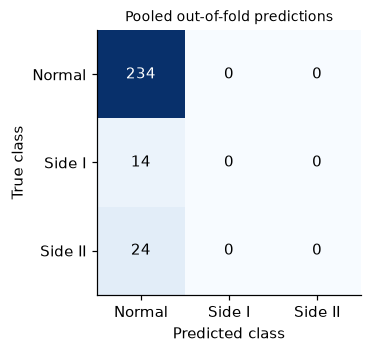

In [18]:
class MajorityClass(FeatureModel):
    """Predicts the most common training class for every recording."""

    def __init__(self):
        self.features = []

    def fit(self, frame):
        self.class_ = frame['label'].value_counts().idxmax()
        return self

    def predict(self, frame):
        return self.output(frame, np.full(len(frame), self.class_, dtype=object))


result = run_experiment('baseline', 'majority_class', MajorityClass, params={'model': 'majority_class'})
show(result)

<blockquote><h3 id="5-2"><b>5.2 Side-Contrast Rule</b></h3></blockquote>

The rule standardises the median same-axle contrast of vibration log RMS (Side I minus Side II) against the
Normal training recordings, using their median and 1.4826 times their median absolute deviation. A recording is
Side I when the standardised contrast exceeds `k`, Side II when it falls below `-k`, and Normal otherwise. The
threshold `k` is the value from 1 to 3 that gives the best macro F1 on the training folds, the larger value
winning ties.

🏃 View run side_contrast_rule at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/8/runs/6695ecea0c694a98b7ab7a038498e06b
🧪 View experiment at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/8


,F1,precision,recall
Normal,0.850,0.863,0.838
Side I,0.111,0.091,0.143
Side II,0.170,0.174,0.167


macro F1 0.377 (95% interval 0.310 to 0.449) | fold mean 0.362 (sd 0.051) | accuracy 0.743 | always Normal 0.308


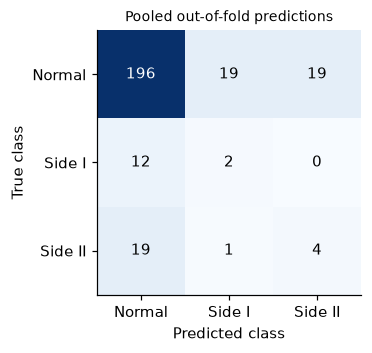

,centre,scale,k
0,-0.026,0.076,2.0
1,-0.029,0.071,1.5
2,-0.029,0.058,1.5
3,-0.029,0.065,2.5


In [19]:
class SideContrastRule(FeatureModel):
    """Flags the rail side whose axle boxes vibrate more than healthy recordings allow."""

    def __init__(self, feature, k_grid):
        self.feature, self.features, self.k_grid = feature, [feature], list(k_grid)

    def standardised(self, frame):
        return ((frame[self.feature] - self.centre_) / self.scale_).to_numpy(dtype=float)

    @staticmethod
    def decide(z, k):
        return np.where(z > k, 'Side I', np.where(z < -k, 'Side II', 'Normal')).astype(object)

    def fit(self, frame):
        normal = frame.loc[frame['label'].eq('Normal'), self.feature].dropna()
        self.centre_ = float(normal.median())
        self.scale_ = float(1.4826 * (normal - self.centre_).abs().median())
        z = self.standardised(frame)
        scores = {k: macro_f1(frame['label'], self.decide(z, k)) for k in self.k_grid}
        self.k_ = max(scores, key=lambda k: (scores[k], k))
        return self

    def predict(self, frame):
        z = self.standardised(frame)
        return self.output(frame, self.decide(z, self.k_)).assign(side_contrast_z=z)


def rule_tables(result):
    """Centre, scale and threshold fitted in every fold."""
    return {'fold_thresholds': pd.DataFrame({fold: {'centre': m.centre_, 'scale': m.scale_, 'k': m.k_}
                                             for fold, m in result['models'].items()}).T}


result = run_experiment('baseline', 'side_contrast_rule',
                        lambda: SideContrastRule(CONFIG['rule_feature'], CONFIG['rule_k_grid']),
                        params={'model': 'side_contrast_rule', 'feature': CONFIG['rule_feature'],
                                'k_grid': ','.join(map(str, CONFIG['rule_k_grid']))}, tables=rule_tables)
show(result)
display(rule_tables(result)['fold_thresholds'].round(3))

<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-6" style="color: black;"><b>Section 6: Logistic Regression</b></h2>
</div>

The first learned model is a multinomial logistic regression on all 101 recording features. Missing wavelength
features are filled with the training median, every feature is standardised with training constants, and the
classes are weighted inversely to their frequency so that the rare fault classes are not ignored. The runs are
recorded in the experiment `rc_logistic_regression`: the full model and three feature-group ablations.

<blockquote><h3 id="6-1"><b>6.1 Logistic Classifier</b></h3></blockquote>

The regularisation strength `C` is chosen from 0.01, 0.1 and 1 by the inner leave-one-fold-out loop on the
training folds, and ties go to the smallest value, the strongest regularisation.

In [20]:
class LogisticClassifier(FeatureModel):
    """Class-weighted multinomial logistic regression on median-imputed, standardised features."""

    def __init__(self, features, c_grid):
        self.features, self.c_grid = list(features), list(c_grid)

    @staticmethod
    def pipeline(c):
        return make_pipeline(SimpleImputer(strategy='median', keep_empty_features=True), StandardScaler(),
                             LogisticRegression(C=c, class_weight='balanced', max_iter=5000))

    def fit(self, frame):
        rows = []
        for inner_train, inner_valid in inner_folds(frame):
            for c in self.c_grid:
                fitted = self.pipeline(c).fit(inner_train[self.features], inner_train['label'])
                rows.append({'c': c, 'macro_f1': macro_f1(inner_valid['label'], fitted.predict(inner_valid[self.features]))})
        self.search_ = pd.DataFrame(rows)
        means = self.search_.groupby('c')['macro_f1'].mean()
        self.c_ = float(means[means == means.max()].index.min())
        self.estimator_ = self.pipeline(self.c_).fit(frame[self.features], frame['label'])
        return self

    def predict(self, frame):
        X = frame[self.features]
        return self.output(frame, self.estimator_.predict(X), self.estimator_.predict_proba(X))


def logistic_params(features):
    return {'model': 'logistic_regression', 'n_features': len(features), 'c_grid': ','.join(map(str, CONFIG['c_grid'])),
            'class_weight': 'balanced', 'imputation': 'training median'}


def logistic_tables(result):
    """Chosen C per fold and the coefficients averaged over the folds."""
    models = result['models']
    coefficients = np.mean([m.estimator_[-1].coef_ for m in models.values()], axis=0)
    return {'fold_c': pd.Series({fold: m.c_ for fold, m in models.items()}, name='c').rename_axis('fold').to_frame(),
            'coefficients': pd.DataFrame(coefficients.T, index=models[FOLD_IDS[0]].features, columns=CLASSES)}

<blockquote><h3 id="6-2"><b>6.2 All Features</b></h3></blockquote>

The full model uses all 101 features and is the candidate from this architecture.

🏃 View run all_features at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/9/runs/0f78934c117648e09ace41e6885fa7ff
🧪 View experiment at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/9


,F1,precision,recall
Normal,0.928,0.947,0.910
Side I,0.242,0.211,0.286
Side II,0.731,0.679,0.792


macro F1 0.634 (95% interval 0.552 to 0.717) | fold mean 0.639 (sd 0.078) | accuracy 0.868 | always Normal 0.308


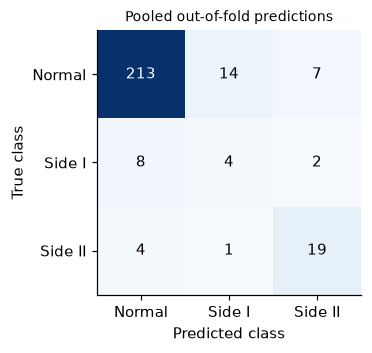

In [21]:
result = run_experiment('logistic_regression', 'all_features', lambda: LogisticClassifier(FEATURES, CONFIG['c_grid']),
                        params=logistic_params(FEATURES), tables=logistic_tables)
show(result)

<blockquote><h3 id="6-3"><b>6.3 Feature-Group Ablations</b></h3></blockquote>

Each ablation changes one part of the input to show what the model relies on: dropping the speed feature, which
is confounded with the class; using the side contrasts alone, the most direct evidence of which side is
affected; and dropping the side contrasts. The amplitude features still carry speed information when speed
itself is dropped. These runs are diagnostics and do not compete in the comparison.

In [22]:
CONTRAST_FEATURES = FEATURE_GROUPS['side contrast']
ABLATIONS = {
    'without_speed': [f for f in FEATURES if f != 'speed_kmh'],
    'side_contrasts_only': CONTRAST_FEATURES,
    'without_side_contrasts': [f for f in FEATURES if f not in CONTRAST_FEATURES],
}
for name, columns in ABLATIONS.items():
    run_experiment('logistic_regression', name, lambda columns=columns: LogisticClassifier(columns, CONFIG['c_grid']),
                   params=logistic_params(columns), role='variant')
display(score_table([('logistic_regression', 'all_features')] + [('logistic_regression', n) for n in ABLATIONS]).round(3))

🏃 View run without_speed at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/9/runs/bacd7d9a52f648eaba9d1b301929b368
🧪 View experiment at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/9


🏃 View run side_contrasts_only at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/9/runs/95ffc4007aba4994ba7c482c02b1d322
🧪 View experiment at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/9


🏃 View run without_side_contrasts at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/9/runs/a4de1d77f84b4017b4fa61013b4a5b9b
🧪 View experiment at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/9


,macro F1,F1 Normal,F1 Side I,F1 Side II
logistic_regression / all_features,0.634,0.928,0.242,0.731
logistic_regression / without_speed,0.634,0.928,0.242,0.731
logistic_regression / side_contrasts_only,0.459,0.781,0.190,0.405
logistic_regression / without_side_contrasts,0.673,0.945,0.368,0.706


<blockquote><h3 id="6-4"><b>6.4 Coefficients</b></h3></blockquote>

The coefficients of the full model, averaged over the four folds, show which standardised features push a
recording towards each fault class. The table lists the eight largest for Side I and for Side II, and the chosen
`C` of each fold is given below it.

In [23]:
tables = logistic_tables(RESULTS[('logistic_regression', 'all_features')])
top = {cls: tables['coefficients'][cls].sort_values(ascending=False).head(8) for cls in ['Side I', 'Side II']}
display(pd.concat({cls: s.rename_axis('feature').rename('coefficient').reset_index() for cls, s in top.items()}, axis=1).round(3))
display(tables['fold_c'].T)

Side I                                                   Side II            
                                      feature coefficient                                       feature coefficient
0                         vibration_I_max_rms       0.763                          vibration_II_max_rms       0.959
1       shock_contrast_w10_20mm_logpow_median       0.498                 shock_contrast_log_rms_median       0.493
2    shock_contrast_w10_20mm_logpow_pos_share       0.317    shock_contrast_w320_640mm_logpow_pos_share       0.354
3               vibration_I_w320_640mm_logpow       0.254     vibration_contrast_w10_20mm_logpow_median       0.347
4                             shock_I_max_rms       0.245  vibration_contrast_w10_20mm_logpow_pos_share       0.256
5      shock_contrast_w80_160mm_logpow_median       0.233                                shock_II_crest       0.233
6           shock_contrast_kurtosis_pos_share       0.227                                 shock_II_peak       0.216
7  vibration_contrast_w80_160mm_logpow_median       0.219         vibration_contrast_kurtosis_pos_share       0.181

fold,0,1,2,3
c,0.1,1.0,1.0,1.0


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-7" style="color: black;"><b>Section 7: Gradient Boosting</b></h2>
</div>

Gradient-boosted trees can use thresholds and interactions, for example a wavelength band that only matters at
some speeds, and they handle the missing wavelength features without imputation. LightGBM is trained on the same
101 features with class weights inversely proportional to class frequency. The runs are recorded in the
experiment `rc_gradient_boosting`.

<blockquote><h3 id="7-1"><b>7.1 LightGBM Classifier</b></h3></blockquote>

With about 200 training recordings per fold, the trees are kept small: seven leaves, at least five recordings per
leaf, 200 rounds at a learning rate of 0.05, with 80% of the recordings and half of the features sampled for
each tree.

In [24]:
class BoostedTreesClassifier(FeatureModel):
    """LightGBM multiclass trees with balanced class weights."""

    def __init__(self, features, params):
        self.features, self.params = list(features), dict(params)

    def fit(self, frame):
        self.estimator_ = lgb.LGBMClassifier(objective='multiclass', class_weight='balanced', random_state=SEED,
                                             deterministic=True, force_row_wise=True, verbose=-1, **self.params)
        self.estimator_.fit(frame[self.features], frame['label'])
        return self

    def predict(self, frame):
        X = frame[self.features]
        return self.output(frame, self.estimator_.predict(X), self.estimator_.predict_proba(X))


def boosting_params(features):
    return {'model': 'lightgbm', 'n_features': len(features), 'class_weight': 'balanced', **CONFIG['lightgbm']}

<blockquote><h3 id="7-2"><b>7.2 All Features</b></h3></blockquote>

The model on all 101 features is the candidate from this architecture.

🏃 View run all_features at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/10/runs/d10b928b9ca942dbacae1021b637c874
🧪 View experiment at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/10


,F1,precision,recall
Normal,0.973,0.959,0.987
Side I,0.560,0.636,0.500
Side II,0.818,0.900,0.750


macro F1 0.784 (95% interval 0.679 to 0.874) | fold mean 0.785 (sd 0.077) | accuracy 0.941 | always Normal 0.308


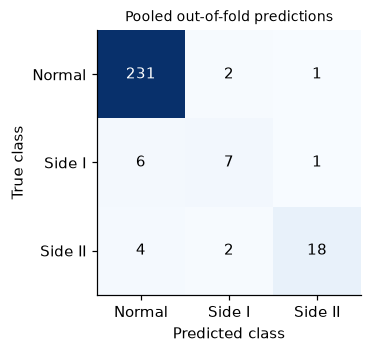

In [25]:
result = run_experiment('gradient_boosting', 'all_features', lambda: BoostedTreesClassifier(FEATURES, CONFIG['lightgbm']),
                        params=boosting_params(FEATURES))
show(result)

<blockquote><h3 id="7-3"><b>7.3 Without Speed</b></h3></blockquote>

As for the logistic regression, one variant drops the speed feature to measure how much the trees rely on it.

In [26]:
NO_SPEED = ABLATIONS['without_speed']
run_experiment('gradient_boosting', 'without_speed', lambda: BoostedTreesClassifier(NO_SPEED, CONFIG['lightgbm']),
               params=boosting_params(NO_SPEED), role='variant')
display(score_table([('gradient_boosting', 'all_features'), ('gradient_boosting', 'without_speed')]).round(3))

🏃 View run without_speed at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/10/runs/904cd063f5574e76b0f19145b56a8db8
🧪 View experiment at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/10


,macro F1,F1 Normal,F1 Side I,F1 Side II
gradient_boosting / all_features,0.784,0.973,0.560,0.818
gradient_boosting / without_speed,0.769,0.968,0.538,0.800


<blockquote><h3 id="7-4"><b>7.4 Feature Importance</b></h3></blockquote>

The total gain of each feature, averaged over the four folds, shows which features the trees split on most. The
table lists the fifteen largest.

In [27]:
gain = pd.DataFrame({fold: pd.Series(m.estimator_.booster_.feature_importance('gain'), index=m.features)
                     for fold, m in RESULTS[('gradient_boosting', 'all_features')]['models'].items()})
display(gain.mean(axis=1).sort_values(ascending=False).head(15).rename('mean gain').to_frame().round(1))

,mean gain
vibration_II_max_rms,889.9
vibration_I_max_rms,447.2
shock_contrast_w10_20mm_logpow_median,361.0
vibration_II_w20_40mm_logpow,178.5
shock_contrast_w10_20mm_logpow_pos_share,139.2
vibration_I_w20_40mm_logpow,106.3
vibration_I_w10_20mm_logpow,88.8
speed_kmh,80.6
shock_II_f500_1500_share,78.7
vibration_contrast_w80_160mm_logpow_median,73.8


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-8" style="color: black;"><b>Section 8: Attention-Based Deep Network</b></h2>
</div>

The last architecture is the team's deep network from `models/RailCorrugation`. Instead of hand-made features, it
reads the raw vibration and shock signal of every axle box. A shared encoder turns each axle box into a vector,
an attention layer weighs the 32 axle boxes of each rail side and pools them, and two output heads estimate the
probability of corrugation on Side I and on Side II, each seeing its own side and the difference between the
sides. The notebook keeps the team's signal preparation, architecture, focal loss, training schedule and
decision rule, with four changes: recordings are read with their header and channels are picked by name; the
shared encoder is applied with `TimeDistributed` layers instead of reshaping lambdas, which computes the same
thing and saves cleanly; the network is evaluated on the four grouped folds like every other model instead of
on one random split; and its early-stopping split is drawn from the training folds only. The runs are recorded in
the experiment `rc_attention_mil`.

<blockquote><h3 id="8-1"><b>8.1 Signal Tensors</b></h3></blockquote>

Each recording becomes two tensors per rail side, one row per axle box (8 cars by 4 positions), each holding the
vibration and the shock signal: the raw signals decimated by 5 to 2,000 samples, and the same signals resampled
onto a distance grid of 5 mm steps over 20 m, so that a corrugation wavelength falls at the same place whatever
the speed. Speed comes from the toothed-wheel pulses (90 teeth, 0.85 m wheel): the time between consecutive
rising edges gives the speed at every sample. As in the team's code, a recording with fewer than two edges is
assumed to move at 20 m/s, the grid beyond the distance travelled is zero, and every signal is standardised on
its own. The same function prepares the input of the packaged model later. The table compares the mean pulse
speed with the preprocessing speed.

In [28]:
SIG = CONFIG['signal']
RAW_COLUMNS = list(read_recording(RAW_PATHS[TRAIN['file_id'].iloc[0]]).columns)
assert RAW_COLUMNS[0] == 'Rotating speed' and sorted(RAW_COLUMNS[1:]) == sorted(channels['column'])
SIGNAL_INPUTS = ['raw_side1', 'ang_side1', 'raw_side2', 'ang_side2']
RAW_LEN = SIG['fs'] // SIG['raw_decimate']
ANG_LEN = int(round(SIG['max_distance_m'] / SIG['distance_step_m']))
side_boxes = {side: channels[channels['side'].eq(side)].pivot(index=['car', 'position'], columns='kind', values='column').sort_index()
              for side in ['Side I', 'Side II']}
SIDE_BOXES = {side: boxes.index.tolist() for side, boxes in side_boxes.items()}
SIDE_CHANNELS = {side: np.array([[RAW_COLUMNS.index(v), RAW_COLUMNS.index(s)] for v, s in zip(boxes['Vibration'], boxes['Shock'])])
                 for side, boxes in side_boxes.items()}
N_BOXES = len(SIDE_BOXES['Side I'])


def pulse_speed(pulse):
    """Speed (m/s) at every sample from the time between consecutive rising pulse edges."""
    rising = np.flatnonzero(np.diff(pulse.astype(int)) == 1) + 1
    speed = np.full(len(pulse), SIG['fallback_speed_mps'])
    if len(rising) >= 2:
        tooth = np.pi * SIG['wheel_diameter_m'] / SIG['teeth']
        for start, end in zip(rising[:-1], rising[1:]):
            speed[start:end] = tooth / ((end - start) / SIG['fs'])
        speed[:rising[0]] = speed[rising[0]]
        speed[rising[-1]:] = speed[rising[-2]]
    return speed


def standardise(x):
    """Zero mean and unit variance along the signal axis, for every axle box and signal."""
    return (x - x.mean(axis=-2, keepdims=True)) / (x.std(axis=-2, keepdims=True) + 1e-6)


def recording_tensors(values):
    """Raw and distance-resampled tensors of both sides from one recording's values (samples by 129 columns)."""
    distance = np.cumsum(pulse_speed(values[:, 0])) / SIG['fs']
    grid = np.arange(ANG_LEN) * SIG['distance_step_m']
    tensors = []
    for side in ['Side I', 'Side II']:
        signals = values[:, SIDE_CHANNELS[side]]
        raw = signals[::SIG['raw_decimate']].transpose(1, 0, 2)
        resampled = np.stack([np.interp(grid, distance, column, left=0.0, right=0.0)
                              for column in signals.reshape(len(signals), -1).T])
        resampled = resampled.reshape(N_BOXES, 2, ANG_LEN).transpose(0, 2, 1)
        tensors += [standardise(raw).astype(np.float32), standardise(resampled).astype(np.float32)]
    return tensors


def signal_batch(file_ids):
    """Signal tensors and labels of the given recordings, in order."""
    index = [SIGNALS['index'][f] for f in file_ids]
    return {'file_id': np.asarray(file_ids, dtype=object),
            'label': RECORDINGS.set_index('file_id').loc[file_ids, 'label'].to_numpy(dtype=object),
            'inputs': [SIGNALS[name][index] for name in SIGNAL_INPUTS]}


def signal_batch_from_table(table):
    """Signal tensors of every recording in a long raw table with one row per recording and sample."""
    file_ids, stacked = [], [[] for _ in SIGNAL_INPUTS]
    for file_id, rows in table.groupby('file_id', sort=False):
        rows = rows.sort_values('sample')
        if not np.array_equal(rows['sample'].to_numpy(), np.arange(SIG['fs'])):
            raise ValueError(f"{file_id}: a recording needs samples 0 to {SIG['fs'] - 1}, each exactly once.")
        file_ids.append(file_id)
        for store, tensor in zip(stacked, recording_tensors(rows[RAW_COLUMNS].to_numpy(dtype=float))):
            store.append(tensor)
    return {'file_id': np.asarray(file_ids, dtype=object), 'label': None, 'inputs': [np.stack(s) for s in stacked]}


start = time.perf_counter()
stacked, speed_rows = [[] for _ in SIGNAL_INPUTS], []
for file_id in RECORDINGS['file_id']:
    values = read_recording(RAW_PATHS[file_id]).to_numpy(dtype=float)
    for store, tensor in zip(stacked, recording_tensors(values)):
        store.append(tensor)
    edges = int((np.diff(values[:, 0].astype(int)) == 1).sum())
    speed_rows.append({'file_id': file_id, 'rising_edges': edges, 'pulse_speed_kmh': pulse_speed(values[:, 0]).mean() * 3.6})
SIGNALS = {'index': {f: i for i, f in enumerate(RECORDINGS['file_id'])},
           **{name: np.stack(store) for name, store in zip(SIGNAL_INPUTS, stacked)}}
speeds = pd.DataFrame(speed_rows).merge(RECORDINGS[['file_id', 'speed_kmh']], on='file_id')
measured = speeds['rising_edges'].ge(2)
display(pd.Series(dtype=object, data={
    'recordings': len(speeds),
    'recordings with at least two rising edges': int(measured.sum()),
    'recordings using the 20 m/s fallback': int((~measured).sum()),
    'largest difference from the preprocessing speed (km/h)': round(float((speeds.loc[measured, 'pulse_speed_kmh'] - speeds.loc[measured, 'speed_kmh']).abs().max()), 2),
    'tensor memory (MB)': round(sum(SIGNALS[name].nbytes for name in SIGNAL_INPUTS) / 1e6),
    'build time (s)': round(time.perf_counter() - start, 1),
}, name='value').to_frame())
print({name: SIGNALS[name].shape for name in SIGNAL_INPUTS})

,value
recordings,340
recordings with at least two rising edges,292
recordings using the 20 m/s fallback,48
largest difference from the preprocessing speed (km/h),0.13
tensor memory (MB),1044
build time (s),9.7


{'raw_side1': (340, 32, 2000, 2), 'ang_side1': (340, 32, 4000, 2), 'raw_side2': (340, 32, 2000, 2), 'ang_side2': (340, 32, 4000, 2)}


<blockquote><h3 id="8-2"><b>8.2 Network Architecture</b></h3></blockquote>

The axle-box encoder has two convolutional branches: a short one over the decimated time signal for shock and
transient content, and a deeper one over the distance-resampled signal, the main evidence of a periodic rail
profile. Each ends in global average pooling and a dense layer, and their outputs are joined into a 64-value
embedding. The same encoder serves every axle box of both sides. Gated attention (Ilse et al., 2018) scores each
axle box of a side, and the attention-weighted mean of the embeddings summarises the side. Each head sees its own
side's summary and the difference between the two sides. A second model exposes the attention weights.

In [29]:
class AttentionMILPooling(layers.Layer):
    """Gated attention pooling over the axle boxes of one side (Ilse et al., 2018)."""

    def __init__(self, attn_dim, **kwargs):
        super().__init__(**kwargs)
        self.attn_dim = attn_dim
        self.dense_v = layers.Dense(attn_dim, activation='tanh')
        self.dense_u = layers.Dense(attn_dim, activation='sigmoid')
        self.dense_w = layers.Dense(1)

    def call(self, x):
        weights = keras.ops.softmax(self.dense_w(self.dense_v(x) * self.dense_u(x)), axis=1)
        return keras.ops.sum(weights * x, axis=1), weights

    def get_config(self):
        return {**super().get_config(), 'attn_dim': self.attn_dim}


def build_network(raw_len, ang_len, n_boxes, embed_dim, attn_dim):
    """The team's network: shared axle-box encoder, gated attention per side and one sigmoid head per side."""
    raw_branch = keras.Sequential([
        layers.Input((raw_len, 2)),
        layers.Conv1D(16, 7, strides=2, padding='same', activation='relu'), layers.BatchNormalization(),
        layers.Conv1D(32, 5, strides=2, padding='same', activation='relu'), layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(), layers.Dense(32, activation='relu')], name='raw_branch')
    distance_branch = keras.Sequential([
        layers.Input((ang_len, 2)),
        layers.Conv1D(32, 15, strides=4, padding='same', activation='relu'), layers.BatchNormalization(),
        layers.Conv1D(64, 9, strides=4, padding='same', activation='relu'), layers.BatchNormalization(),
        layers.Conv1D(64, 5, strides=2, padding='same', activation='relu'), layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(), layers.Dense(64, activation='relu')], name='distance_branch')
    raw_encoder = layers.TimeDistributed(raw_branch, name='raw_encoder')
    distance_encoder = layers.TimeDistributed(distance_branch, name='distance_encoder')
    embedding = layers.Dense(embed_dim, activation='relu', name='embedding')
    inputs, summaries, attention = [], [], []
    for side in ['side1', 'side2']:
        raw_in = layers.Input((n_boxes, raw_len, 2), name=f'raw_{side}')
        ang_in = layers.Input((n_boxes, ang_len, 2), name=f'ang_{side}')
        embedded = embedding(layers.Concatenate(name=f'join_{side}')([raw_encoder(raw_in), distance_encoder(ang_in)]))
        summary, weights = AttentionMILPooling(attn_dim, name=f'attention_{side}')(embedded)
        inputs += [raw_in, ang_in]
        summaries.append(summary)
        attention.append(weights)
    difference = layers.Subtract(name='side_difference')(summaries)
    outputs = []
    for side, summary in zip(['side1', 'side2'], summaries):
        hidden = layers.Dense(32, activation='relu', name=f'{side}_hidden')(layers.Concatenate(name=f'{side}_features')([summary, difference]))
        outputs.append(layers.Dense(1, activation='sigmoid', name=f'{side}_out')(hidden))
    return keras.Model(inputs, outputs, name='corrugation_mil'), keras.Model(inputs, attention, name='attention_weights')


network, _ = build_network(RAW_LEN, ANG_LEN, N_BOXES, CONFIG['attention_mil']['embed_dim'], CONFIG['attention_mil']['attn_dim'])
display(pd.Series({layer.name: layer.count_params() for layer in network.layers if layer.count_params()}, name='parameters').to_frame())
print('Total parameters:', network.count_params())

,parameters
raw_encoder,4080
distance_encoder,44832
embedding,6208
attention_side1,8385
attention_side2,8385
side1_hidden,4128
side2_hidden,4128
side1_out,33
side2_out,33


Total parameters: 80212


<blockquote><h3 id="8-3"><b>8.3 Training and Decision Rule</b></h3></blockquote>

Each head is trained with the team's binary focal loss (gamma 2), whose alpha gives the positive class a weight of
one minus its frequency among the training recordings, so that rare corrugation examples count more. Adam starts
at a learning rate of 0.001 with batches of 8; the rate halves after 8 epochs without improvement in validation
loss, and training stops after 20 such epochs, keeping the best weights, or after 150 epochs. The validation
loss comes from a stratified 15% of the fold's training recordings. A recording is Side I or Side II when that
head's probability reaches 0.5, the more probable side when both do, and Normal otherwise. For packaging, the
classifier stores the network's weights and rebuilds it when loaded.

In [30]:
def decide(p_side1, p_side2, threshold):
    """The team's decision rule for the two side probabilities."""
    both = (p_side1 >= threshold) & (p_side2 >= threshold)
    single = np.where(p_side1 >= threshold, 'Side I', np.where(p_side2 >= threshold, 'Side II', 'Normal'))
    return np.where(both, np.where(p_side1 >= p_side2, 'Side I', 'Side II'), single).astype(object)


class AttentionMILClassifier:
    """The team's attention network trained on signal tensors, with one focal-loss head per rail side."""

    input_level = 'signal'
    row_key = ['file_id', 'sample']

    def __init__(self, settings):
        self.settings = dict(settings)

    @property
    def input_columns(self):
        return ['file_id', 'sample'] + RAW_COLUMNS

    def build(self):
        keras.utils.set_random_seed(SEED)
        return build_network(RAW_LEN, ANG_LEN, N_BOXES, self.settings['embed_dim'], self.settings['attn_dim'])

    def fit(self, batch):
        s, labels = self.settings, batch['label']
        targets = [(labels == side).astype('float32')[:, None] for side in ['Side I', 'Side II']]
        train_idx, valid_idx = train_test_split(np.arange(len(labels)), test_size=s['validation_share'],
                                                random_state=SEED, stratify=labels)
        self.network_, self.attention_ = self.build()
        self.alphas_ = [1.0 - float(t[train_idx].mean()) for t in targets]
        self.network_.compile(optimizer=keras.optimizers.Adam(s['learning_rate']),
                              loss=[keras.losses.BinaryFocalCrossentropy(apply_class_balancing=True, alpha=a, gamma=s['focal_gamma'])
                                    for a in self.alphas_])
        callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=s['early_stopping_patience'], restore_best_weights=True),
                     keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=s['lr_factor'], patience=s['lr_patience'],
                                                       min_lr=s['min_lr'])]
        history = self.network_.fit([x[train_idx] for x in batch['inputs']], [t[train_idx] for t in targets],
                                    validation_data=([x[valid_idx] for x in batch['inputs']], [t[valid_idx] for t in targets]),
                                    batch_size=s['batch_size'], epochs=s['max_epochs'], callbacks=callbacks, verbose=0)
        self.history_ = pd.DataFrame(history.history).rename_axis('epoch')
        return self

    def predict(self, batch):
        p_side1, p_side2 = (p.ravel() for p in self.network_.predict(batch['inputs'], batch_size=32, verbose=0))
        return pd.DataFrame({'file_id': batch['file_id'], 'prediction': decide(p_side1, p_side2, self.settings['threshold']),
                             'p_side_i': p_side1, 'p_side_ii': p_side2})

    def predict_table(self, table):
        return self.predict(signal_batch_from_table(table))

    def __getstate__(self):
        state = {k: v for k, v in self.__dict__.items() if k not in ('network_', 'attention_')}
        if 'network_' in self.__dict__:
            state['weights_'] = self.network_.get_weights()
        return state

    def __setstate__(self, state):
        self.__dict__.update(state)
        if 'weights_' in state:
            self.network_, self.attention_ = self.build()
            self.network_.set_weights(state['weights_'])


def mil_tables(result):
    """Training history of every fold."""
    return {'training_history': pd.concat({fold: m.history_ for fold, m in result['models'].items()}, names=['fold'])}

<blockquote><h3 id="8-4"><b>8.4 Cross-Validated Training</b></h3></blockquote>

A fresh network is trained for each of the four folds. This is the slowest step of the notebook, a few minutes
per fold on a laptop CPU. The network is the candidate from this architecture.

🏃 View run attention_mil at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/11/runs/fc97075ed06f42a5a0dd38a56456a568
🧪 View experiment at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/11


,F1,precision,recall
Normal,0.822,0.960,0.718
Side I,0.186,0.138,0.286
Side II,0.435,0.294,0.833


macro F1 0.481 (95% interval 0.417 to 0.548) | fold mean 0.481 (sd 0.097) | accuracy 0.706 | always Normal 0.308


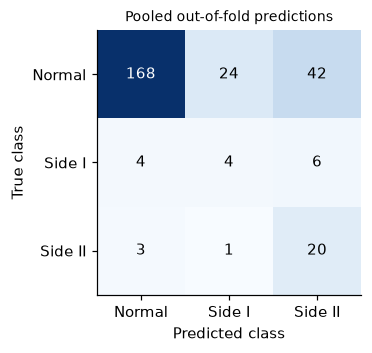

In [31]:
result = run_experiment('attention_mil', 'attention_mil', lambda: AttentionMILClassifier(CONFIG['attention_mil']),
                        params={'model': 'attention_mil', **CONFIG['attention_mil'],
                                **{f'signal_{k}': v for k, v in SIG.items()}}, tables=mil_tables)
show(result)

<blockquote><h3 id="8-5"><b>8.5 Training Curves</b></h3></blockquote>

The focal loss of both heads on the training and early-stopping recordings of each fold shows how long each
network trained and whether it overfitted; the table gives the epochs run and the epoch with the lowest
validation loss.

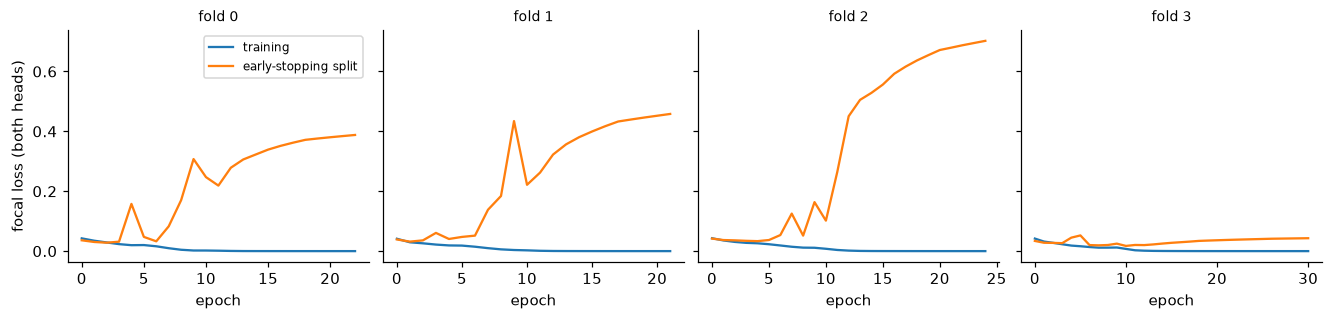

,epochs run,best epoch,best validation loss
fold,,,
0,23,3,0.0282
1,22,2,0.0318
2,25,5,0.0334
3,31,11,0.0174


In [32]:
mil_models = RESULTS[('attention_mil', 'attention_mil')]['models']
fig, axes = plt.subplots(1, len(mil_models), figsize=(12, 2.8), sharey=True)
for ax, (fold, model) in zip(axes, mil_models.items()):
    ax.plot(model.history_['loss'], label='training')
    ax.plot(model.history_['val_loss'], label='early-stopping split')
    ax.set_title(f'fold {fold}', fontsize=9)
    ax.set_xlabel('epoch')
axes[0].set_ylabel('focal loss (both heads)')
axes[0].legend(fontsize=8)
plt.show()
display(pd.DataFrame([{'fold': fold, 'epochs run': len(m.history_), 'best epoch': int(m.history_['val_loss'].idxmin()) + 1,
                       'best validation loss': round(float(m.history_['val_loss'].min()), 4)}
                      for fold, m in mil_models.items()]).set_index('fold'))

<blockquote><h3 id="8-6"><b>8.6 Attention by Axle Box</b></h3></blockquote>

For each held-out Side I or Side II recording, the attention weights of its corrugated side show which axle boxes
the network relied on. The maps average them by car and position over the recordings of each fault class; an
even spread would give every axle box 1/32, about 0.031.

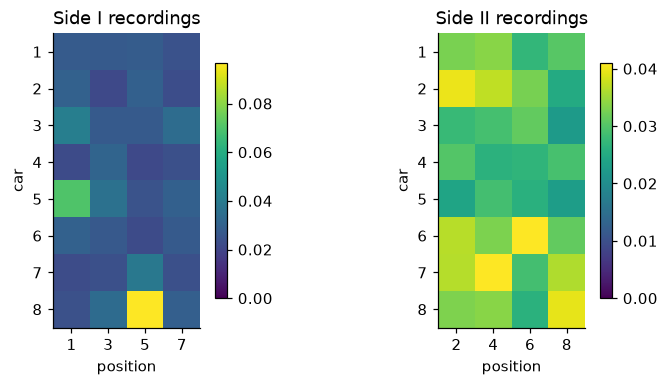

In [33]:
attention_rows = []
for fold, model in mil_models.items():
    held = TRAIN.loc[TRAIN['fold'].eq(fold) & TRAIN['label'].ne('Normal'), 'file_id'].tolist()
    batch = signal_batch(held)
    weights = model.attention_.predict(batch['inputs'], verbose=0)
    for i, label in enumerate(batch['label']):
        side_weights = weights[0 if label == 'Side I' else 1][i, :, 0]
        for (car, position), weight in zip(SIDE_BOXES[label], side_weights):
            attention_rows.append({'label': label, 'car': car, 'position': position, 'weight': weight})
attention_table = pd.DataFrame(attention_rows)
fig, axes = plt.subplots(1, 2, figsize=(7, 3.4))
for ax, label in zip(axes, ['Side I', 'Side II']):
    grid = attention_table[attention_table['label'].eq(label)].pivot_table(index='car', columns='position', values='weight')
    image = ax.imshow(grid.to_numpy(), cmap='viridis', vmin=0)
    ax.set(xticks=range(grid.shape[1]), xticklabels=grid.columns, yticks=range(grid.shape[0]), yticklabels=grid.index,
           xlabel='position', ylabel='car', title=f'{label} recordings')
    fig.colorbar(image, ax=ax, shrink=0.8)
plt.show()

<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-9" style="color: black;"><b>Section 9: Model Comparison</b></h2>
</div>

This section puts all architectures side by side, using the runs as recorded in MLflow, and selects the model to
carry forward.

<blockquote><h3 id="9-1"><b>9.1 Results Across Experiments</b></h3></blockquote>

The runs of this execution are read back from the tracking server by their `notebook_run` tag, so the comparison
uses exactly what was recorded. The table lists every run in the order it was built, with its pooled
out-of-fold macro F1, the bootstrap interval, the F1 of each class and the accuracy.

In [34]:
EXPERIMENTS = [f'rc_{arch}' for arch in dict.fromkeys(arch for arch, _ in RESULTS)]
LABELS = [f'{arch} / {name}' for arch, name in RESULTS]
experiment_names = {experiment_id(name): name.removeprefix('rc_') for name in EXPERIMENTS}
runs = mlflow.search_runs(experiment_names=EXPERIMENTS, filter_string=f"tags.notebook_run = '{NOTEBOOK_RUN}'")
runs.index = runs['experiment_id'].map(experiment_names) + ' / ' + runs['tags.mlflow.runName']
runs = runs[runs['tags.role'].ne('final')].reindex(LABELS)
assert runs['run_id'].notna().all(), 'Some runs of this execution were not found on the tracking server.'
COMPARISON = pd.DataFrame({'role': runs['tags.role'], 'macro F1': runs['metrics.macro_f1'],
                           'CI low': runs['metrics.macro_f1_ci_low'], 'CI high': runs['metrics.macro_f1_ci_high'],
                           **{f'F1 {cls}': runs[f'metrics.f1_{k}'] for cls, k in CLASS_KEYS.items()},
                           'accuracy': runs['metrics.accuracy']})
display(COMPARISON.round(3))

,role,macro F1,CI low,CI high,F1 Normal,F1 Side I,F1 Side II,accuracy
baseline / majority_class,candidate,0.308,0.308,0.308,0.925,0.000,0.000,0.860
baseline / side_contrast_rule,candidate,0.377,0.310,0.449,0.850,0.111,0.170,0.743
logistic_regression / all_features,candidate,0.634,0.552,0.717,0.928,0.242,0.731,0.868
logistic_regression / without_speed,variant,0.634,0.552,0.717,0.928,0.242,0.731,0.868
logistic_regression / side_contrasts_only,variant,0.459,0.398,0.523,0.781,0.190,0.405,0.662
logistic_regression / without_side_contrasts,variant,0.673,0.588,0.759,0.945,0.368,0.706,0.882
gradient_boosting / all_features,candidate,0.784,0.679,0.874,0.973,0.560,0.818,0.941
gradient_boosting / without_speed,variant,0.769,0.667,0.860,0.968,0.538,0.800,0.934
attention_mil / attention_mil,candidate,0.481,0.417,0.548,0.822,0.186,0.435,0.706


<blockquote><h3 id="9-2"><b>9.2 Comparison Plot</b></h3></blockquote>

The plot shows the pooled macro F1 of every run with its bootstrap interval. Candidates, one or two per
architecture, are coloured; diagnostic variants are grey. The dashed line is the score of always predicting
Normal.

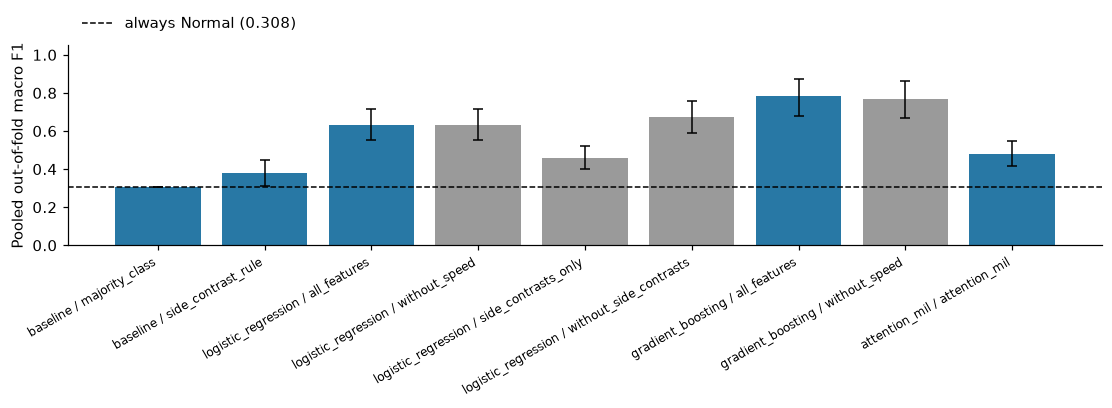

In [35]:
comparison_figure(COMPARISON)
plt.show()

<blockquote><h3 id="9-3"><b>9.3 Model Selection</b></h3></blockquote>

The selected model is the candidate with the highest pooled macro F1. When candidates tie, the simplest wins,
following the order in which the architectures were built, since added complexity has to earn its place. Three
points limit what the comparison can show. With 14 Side I and 24 Side II recordings, one more or one fewer
correct fault recording moves macro F1 by about 0.01 to 0.02, so small differences are not meaningful. Speed is
confounded with the class, so part of any score may come from speed rather than from corrugation. And the
deep network was trained once with one seed, so its score carries some training randomness as well.

In [36]:
candidates = COMPARISON[COMPARISON['role'].eq('candidate')]
best = candidates.index[np.isclose(candidates['macro F1'], candidates['macro F1'].max())].tolist()
SELECTED = list(RESULTS)[LABELS.index(best[0])]
client.set_tag(RESULTS[SELECTED]['run_id'], 'selected', 'true')
display(candidates.drop(columns='role').assign(selected=candidates.index == best[0]).round(3))
print('Selected:', best[0], '| other candidates with the same score:', ', '.join(best[1:]) or 'none')

,macro F1,CI low,CI high,F1 Normal,F1 Side I,F1 Side II,accuracy,selected
baseline / majority_class,0.308,0.308,0.308,0.925,0.000,0.000,0.860,False
baseline / side_contrast_rule,0.377,0.310,0.449,0.850,0.111,0.170,0.743,False
logistic_regression / all_features,0.634,0.552,0.717,0.928,0.242,0.731,0.868,False
gradient_boosting / all_features,0.784,0.679,0.874,0.973,0.560,0.818,0.941,True
attention_mil / attention_mil,0.481,0.417,0.548,0.822,0.186,0.435,0.706,False


Selected: gradient_boosting / all_features | other candidates with the same score: none


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-10" style="color: black;"><b>Section 10: Final Model</b></h2>
</div>

This section refits the selected configuration on all Train recordings, packages it as an MLflow model with input
checks, registers it, and classifies the Test recordings.

<blockquote><h3 id="10-1"><b>10.1 Refit on All Train Recordings</b></h3></blockquote>

The selected configuration is fitted on all 272 Train recordings in a run named `final_refit`, inside the
experiment of its architecture and linked to the evaluation run it came from. No score is reported for the
refit, because it would be measured on the recordings it was fitted on.

In [37]:
ARCH, NAME = SELECTED
chosen = RESULTS[SELECTED]
FINAL_MODEL = chosen['make_model']()
start = time.perf_counter()
FINAL_MODEL.fit(frame_for(FINAL_MODEL.input_level, TRAIN['file_id']))
fit_seconds = time.perf_counter() - start
with mlflow.start_run(experiment_id=experiment_id(f'rc_{ARCH}'), run_name='final_refit',
                      tags={'notebook_run': NOTEBOOK_RUN, **GIT, 'data_version': DATA_VERSION, 'role': 'final',
                            'evaluation_run_id': chosen['run_id']}) as final_run:
    mlflow.log_params({**chosen['params'], 'training_recordings': len(TRAIN), 'seed': SEED})
    mlflow.log_metric('fit_time_s', fit_seconds)
FINAL_RUN_ID = final_run.info.run_id
display(pd.Series({'experiment': f'rc_{ARCH}', 'configuration': NAME, **chosen['params']}, name='value').to_frame())

🏃 View run final_refit at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/10/runs/7fa95b7255c04d51ac2c2d0d8f6c7058
🧪 View experiment at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/10


,value
experiment,rc_gradient_boosting
configuration,all_features
model,lightgbm
n_features,101
class_weight,balanced
n_estimators,200
learning_rate,0.05
num_leaves,7
min_child_samples,5
subsample,0.8


<blockquote><h3 id="10-2"><b>10.2 Model Package</b></h3></blockquote>

The fitted model is wrapped as an MLflow Python model. Its input is what the model was trained on, always with a
`file_id` column: one row of recording features per recording for the feature models, or, for the deep network,
the raw recording as one row per sample with its 129 recorded columns and a `sample` number from 0 to 9,999. The
wrapper rejects missing columns, repeated rows and infinite values, the deep network also rejects incomplete
recordings, and the output gives each recording's predicted class with the model's probabilities. Raw
recordings are read into this long table by a small helper.

In [38]:
class RailPackage(mlflow.pyfunc.PythonModel):
    """Checks the input table, then classifies every recording in it."""

    def __init__(self, model):
        self.model = model

    def predict(self, context, model_input: pd.DataFrame, params=None) -> pd.DataFrame:
        frame = pd.DataFrame(model_input)
        missing = [c for c in self.model.input_columns if c not in frame.columns]
        if missing:
            raise ValueError(f'Missing required columns: {missing[:5]}')
        if frame.duplicated(self.model.row_key).any():
            raise ValueError(f'Rows must be unique by {self.model.row_key}.')
        if np.isinf(frame[self.model.input_columns].select_dtypes('number').to_numpy(dtype=float)).any():
            raise ValueError('Values must be finite or missing.')
        return self.model.predict_table(frame[self.model.input_columns])


def raw_table(file_ids):
    """Raw recordings as one long table: one row per recording and sample, with the 129 recorded columns."""
    parts = []
    for file_id in file_ids:
        frame = read_recording(RAW_PATHS[file_id])
        parts.append(frame.assign(file_id=file_id, sample=np.arange(len(frame)))[['file_id', 'sample'] + RAW_COLUMNS])
    return pd.concat(parts, ignore_index=True)


def model_input(file_ids):
    """Package input for the given recordings, in the form the final model expects."""
    if FINAL_MODEL.input_level == 'signal':
        return raw_table(file_ids)
    return FEATURE_TABLE.set_index('file_id').loc[list(file_ids)].reset_index()[FINAL_MODEL.input_columns]


PACKAGE = RailPackage(FINAL_MODEL)
EXAMPLE = model_input(TRAIN['file_id'].head(2 if FINAL_MODEL.input_level == 'signal' else 5))
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', message='Hint: Inferred schema contains integer')  # `sample` is an integer by design
    SIGNATURE = infer_signature(EXAMPLE, PACKAGE.predict(None, EXAMPLE))
display(PACKAGE.predict(None, EXAMPLE))

,file_id,prediction,p_normal,p_side_i,p_side_ii
0,Train1.csv,Normal,0.999434,0.000283,0.000284
1,Train2.csv,Side II,0.005204,0.003303,0.991493
2,Train3.csv,Normal,0.987105,0.002189,0.010706
3,Train4.csv,Normal,0.997152,0.001368,0.001480
4,Train5.csv,Normal,0.999647,0.000197,0.000156


<blockquote><h3 id="10-3"><b>10.3 Registration</b></h3></blockquote>

The package is logged to the `final_refit` run with its signature and pinned requirements, and registered as a
new version of `rc_corrugation_classifier` with a short description; feature models also store an input
example, which would be too large for raw recordings. The new version receives the `champion` alias. The model
is serialised with cloudpickle because it is defined in this notebook.

In [39]:
PINS = [f'{n}=={importlib.metadata.version(n)}' for n in
        ['mlflow', 'numpy', 'pandas', 'scikit-learn', 'lightgbm', 'tensorflow', 'keras', 'cloudpickle']]
DESCRIPTION = (f"Classifies each one-second rail corrugation recording as Normal, Side I or Side II. Configuration "
               f"{ARCH} / {NAME}, refitted on the 272 Train recordings; pooled out-of-fold macro F1 "
               f"{chosen['summary']['macro_f1']:.3f} on the four grouped folds.")
pyfunc_logger = logging.getLogger('mlflow.pyfunc')
previous_level = pyfunc_logger.level
pyfunc_logger.setLevel(logging.ERROR)  # silences the notice about pickled models, which are produced here
try:
    with mlflow.start_run(run_id=FINAL_RUN_ID), warnings.catch_warnings():
        warnings.filterwarnings('ignore', message='An input example was not provided')  # raw recordings are too large
        MODEL_INFO = mlflow.pyfunc.log_model(name='model', python_model=PACKAGE, signature=SIGNATURE, pip_requirements=PINS,
                                             input_example=EXAMPLE if FINAL_MODEL.input_level == 'features' else None)
finally:
    pyfunc_logger.setLevel(previous_level)
with contextlib.redirect_stderr(io.StringIO()):
    MODEL_VERSION = mlflow.register_model(MODEL_INFO.model_uri, CONFIG['registered_model']).version
client.update_model_version(CONFIG['registered_model'], MODEL_VERSION, description=DESCRIPTION)
client.set_registered_model_alias(CONFIG['registered_model'], 'champion', MODEL_VERSION)
print(f"Registered {CONFIG['registered_model']} version {MODEL_VERSION} with alias champion.")

🏃 View run final_refit at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/10/runs/7fa95b7255c04d51ac2c2d0d8f6c7058
🧪 View experiment at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/10


Registered rc_corrugation_classifier version 1 with alias champion.


<blockquote><h3 id="10-4"><b>10.4 Submission Format</b></h3></blockquote>

The submission file `rail_predictions.csv` has one row per Test recording: `file_id`, the recording's file name
with its extension, and `prediction`, one of `Normal`, `Side I` and `Side II`. The validator is tested on two
malformed tables.

In [40]:
def export_rows(predicted):
    """One `file_id,prediction` row per recording, in recording-number order."""
    rows = predicted[['file_id', 'prediction']].copy()
    return rows.sort_values('file_id', key=lambda s: s.str.extract(r'(\d+)')[0].astype(int)).reset_index(drop=True)


def validate_export(rows, expected_files):
    """Every problem with a submission table: columns, file names and class labels."""
    problems = []
    if list(rows.columns) != ['file_id', 'prediction']:
        problems.append('columns must be file_id,prediction')
    if rows['file_id'].duplicated().any():
        problems.append('repeated file_id')
    if sorted(rows['file_id']) != sorted(expected_files):
        problems.append('file_id must list every expected recording, with its .csv extension')
    if not rows['prediction'].isin(CLASSES).all():
        problems.append(f'prediction must be one of {CLASSES}')
    return problems


TEST_FILES = RECORDINGS.loc[RECORDINGS['dataset'].eq('Test'), 'file_id'].tolist()
display(pd.DataFrame({'table': ['Test1 without its extension', 'Test1 predicted as "Side 1"'],
                      'problems found': [validate_export(pd.DataFrame({'file_id': ['Test1'], 'prediction': ['Normal']}), ['Test1.csv']),
                                         validate_export(pd.DataFrame({'file_id': ['Test1.csv'], 'prediction': ['Side 1']}), ['Test1.csv'])]}))

,table,problems found
0,Test1 without its extension,"[file_id must list every expected recording, w..."
1,"Test1 predicted as ""Side 1""","[prediction must be one of ['Normal', 'Side I'..."


<blockquote><h3 id="10-5"><b>10.5 Package Checks</b></h3></blockquote>

The registered version is loaded back from the registry and applied to a fixture of Train recordings: all of them
for a feature model, or eight raw recordings for the deep network. It has to reproduce the predictions of the
fitted model, reject each kind of malformed input, and produce predictions that pass the submission format.

In [41]:
LOADED = mlflow.pyfunc.load_model(f"models:/{CONFIG['registered_model']}@champion")
FIXTURE_FILES = TRAIN['file_id'].head(8).tolist() if FINAL_MODEL.input_level == 'signal' else TRAIN['file_id'].tolist()
FIXTURE = model_input(FIXTURE_FILES)
expected, reloaded = FINAL_MODEL.predict_table(FIXTURE), LOADED.predict(FIXTURE)
probability_columns = [c for c in expected.columns if c.startswith('p_')]


def rejects(frame):
    """True when the registered version refuses `frame`."""
    try:
        LOADED.predict(frame)
    except Exception:
        return True
    return False


last = FINAL_MODEL.input_columns[-1]
PACKAGE_CHECKS = {
    'reproduces the fitted predictions': bool(
        expected[['file_id', 'prediction']].equals(reloaded[['file_id', 'prediction']])
        and np.allclose(expected[probability_columns], reloaded[probability_columns], rtol=0, atol=1e-6)),
    'rejects a missing column': rejects(FIXTURE.drop(columns=[last])),
    'rejects a repeated row': rejects(pd.concat([FIXTURE.head(1), FIXTURE])),
    'rejects infinite values': rejects(FIXTURE.assign(**{last: np.inf})),
    'predictions pass the submission format': not validate_export(export_rows(reloaded), FIXTURE_FILES),
}
if FINAL_MODEL.input_level == 'signal':
    PACKAGE_CHECKS['rejects an incomplete recording'] = rejects(FIXTURE.iloc[:-100])
assert all(PACKAGE_CHECKS.values())
display(pd.Series(PACKAGE_CHECKS, name='passed').to_frame())

,passed
reproduces the fitted predictions,True
rejects a missing column,True
rejects a repeated row,True
rejects infinite values,True
predictions pass the submission format,True


<blockquote><h3 id="10-6"><b>10.6 Test Predictions</b></h3></blockquote>

The Test recordings are classified only now, after the model has been selected and registered, so they could not
influence any modelling choice. The registered version classifies them, eight at a time for raw recordings, and
the result is converted to the submission format, validated, read back, and attached to the `final_refit` run.

In [42]:
chunks = [TEST_FILES[i:i + 8] for i in range(0, len(TEST_FILES), 8)] if FINAL_MODEL.input_level == 'signal' else [TEST_FILES]
TEST_PREDICTED = pd.concat([LOADED.predict(model_input(chunk)) for chunk in chunks], ignore_index=True)
SUBMISSION = export_rows(TEST_PREDICTED)
assert not validate_export(SUBMISSION, TEST_FILES)
SUBMISSION_PATH = OUTPUT_DIR / 'rail_predictions.csv'
SUBMISSION.to_csv(SUBMISSION_PATH, index=False)
assert pd.read_csv(SUBMISSION_PATH, dtype=str).equals(SUBMISSION.astype(str))
with mlflow.start_run(run_id=FINAL_RUN_ID):
    mlflow.log_artifact(str(SUBMISSION_PATH))
    mlflow.log_text(TEST_PREDICTED.to_csv(index=False), 'test_predictions.csv')
display(SUBMISSION['prediction'].value_counts().reindex(CLASSES, fill_value=0).rename('Test recordings').to_frame())
display(SUBMISSION.head(10))

🏃 View run final_refit at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/10/runs/7fa95b7255c04d51ac2c2d0d8f6c7058
🧪 View experiment at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/10


,Test recordings
prediction,
Normal,60
Side I,2
Side II,6


,file_id,prediction
0,Test1.csv,Normal
1,Test2.csv,Normal
2,Test3.csv,Normal
3,Test4.csv,Normal
4,Test5.csv,Normal
5,Test6.csv,Normal
6,Test7.csv,Normal
7,Test8.csv,Normal
8,Test9.csv,Side II
9,Test10.csv,Normal


<blockquote><h3 id="10-7"><b>10.7 Test Predictions by Speed</b></h3></blockquote>

Corrugated Train recordings occur only above 20 km/h. The table sets the Train labels of each speed band against
the Test predictions; a fault predicted in a band without any corrugated Train recording would rest on no
training evidence. No Test label is inferred from it.

In [43]:
test_bands = TEST_PREDICTED.merge(RECORDINGS[['file_id', 'speed_band']], on='file_id')
test_profile = pd.crosstab(test_bands['speed_band'], test_bands['prediction'])
train_profile = pd.crosstab(TRAIN['speed_band'], TRAIN['label'])
display(pd.concat({'Train labels': train_profile.reindex(index=BANDS, columns=CLASSES, fill_value=0),
                   'Test predictions': test_profile.reindex(index=BANDS, columns=CLASSES, fill_value=0)}, axis=1))

Train labels                Test predictions               
label            Normal Side I Side II           Normal Side I Side II
speed_band                                                            
stationary           42      0       0                9      0       0
0.5-20               58      0       0                9      0       0
20-40                55      2       0               15      0       1
40-60                58      9      19               24      2       4
60-80                21      3       5                3      0       1

<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-11" style="color: black;"><b>Section 11: Conclusions</b></h2>
</div>

This section summarises what each architecture achieved, the model that was carried forward, and the limits of
the evidence. All statements refer to the executed results above.

<blockquote><h3 id="11-1"><b>11.1 Results by Architecture</b></h3></blockquote>

- **Baseline.** Always predicting Normal scored a macro F1 of 0.308, with an F1 of 0 for both fault classes. The
  side-contrast rule scored 0.377 (bootstrap interval 0.310 to 0.449), with F1 0.111 for Side I and 0.170 for
  Side II. Its statistic barely separates Side I from Normal: the median vibration contrast is -0.025 for Side I,
  -0.029 for Normal and -0.077 for Side II.
- **Logistic regression.** On all 101 features it scored 0.634 (0.552 to 0.717), with F1 0.242 for Side I and
  0.731 for Side II. Dropping speed changed no predicted class. The side contrasts alone scored 0.459, and
  dropping them raised the score to 0.673. The largest coefficients for Side I and Side II were the largest
  vibration RMS on the matching side.
- **Gradient boosting.** LightGBM scored 0.784 (0.679 to 0.874), with F1 0.973 for Normal, 0.560 for Side I and
  0.818 for Side II, and an accuracy of 0.941. Without speed it scored 0.769. The trees gained most from the
  largest vibration RMS of Side II and of Side I, followed by the shock contrast in the 10 to 20 mm wavelength
  band.
- **Attention network.** The team's network scored 0.481 (0.417 to 0.548), with F1 0.186 for Side I and 0.435
  for Side II. It found 20 of the 24 Side II recordings but also labelled 66 of the 234 Normal recordings as
  faults. In every fold, its training loss fell towards zero while the early-stopping loss was lowest after 2 to
  11 epochs and then rose, so the network overfitted the roughly 170 training recordings of each fold. Its
  attention on Side I recordings concentrated on a few axle boxes, most on car 8, position 5; on Side II
  recordings it stayed close to an even spread.

<blockquote><h3 id="11-2"><b>11.2 Selected Model and Test Predictions</b></h3></blockquote>

- Gradient boosting on all features had the highest pooled macro F1 of the candidates, 0.784 against 0.634 for
  the logistic regression, 0.481 for the attention network and 0.377 for the side-contrast rule, and was
  selected.
- It was refitted on all 272 Train recordings and registered as version 1 of `rc_corrugation_classifier` with the
  alias `champion`. The registered version reproduced the fitted predictions and passed every package check.
- On the 68 Test recordings it predicts 60 Normal, 2 Side I and 6 Side II. None of the 18 stationary or
  below-20 km/h Test recordings is predicted as a fault. One Side II prediction falls in the 20 to 40 km/h band,
  where the Train set has no Side II recording.

<blockquote><h3 id="11-3"><b>11.3 Limitations</b></h3></blockquote>

- The fault classes are small. The selected model's interval spans 0.679 to 0.874. It found 7 of the 14 Side I
  recordings, and Side I has the lowest F1 of the three classes for every model that predicts faults.
- The explicit speed feature adds little: removing it cost gradient boosting 0.015 and changed no logistic
  prediction. However, the largest-RMS features that drive both feature models also rise with speed, so part of
  their signal may still be speed.
- The folds keep identical recordings together, but no run, route or session metadata is available. Recordings
  from the same run may still fall on both sides of a split, which would make the held-out scores optimistic.
- The features and the rule's statistic were designed during the exploratory analysis with the Train labels in
  view.
- The attention network was trained once, with one seed, on about 170 recordings per fold, using the team's
  settings. Its score shows how this configuration behaves on this amount of data, not the limit of the
  architecture.